In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df=pd.read_csv(r"/content/drive/MyDrive/archive (1)/Salary Data.csv")
print(df)

      Age  Gender Education Level                      Job Title  \
0    32.0    Male      Bachelor's              Software Engineer   
1    28.0  Female        Master's                   Data Analyst   
2    45.0    Male             PhD                 Senior Manager   
3    36.0  Female      Bachelor's                Sales Associate   
4    52.0    Male        Master's                       Director   
..    ...     ...             ...                            ...   
370  35.0  Female      Bachelor's       Senior Marketing Analyst   
371  43.0    Male        Master's         Director of Operations   
372  29.0  Female      Bachelor's         Junior Project Manager   
373  34.0    Male      Bachelor's  Senior Operations Coordinator   
374  44.0  Female             PhD        Senior Business Analyst   

     Years of Experience    Salary  
0                    5.0   90000.0  
1                    3.0   65000.0  
2                   15.0  150000.0  
3                    7.0   60000.0 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [ ]:
df.shape

(375, 6)

In [ ]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [ ]:
#numerical by mean
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Years of Experience'].fillna(df['Years of Experience'].mean(),inplace=True)
df['Salary'].fillna(df['Salary'].mean(), inplace=True)

#categorical by mode
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Education Level'].fillna(df['Education Level'].mode()[0],inplace=True)
df['Job Title'].fillna(df['Job Title'].mode()[0],inplace=True)

/tmp/ipykernel_7433/3138400533.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_7433/3138400533.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [ ]:
#Now we start the label encoding
from sklearn.preprocessing import LabelEncoder
LE_Gender=LabelEncoder()
LE_Job_Title=LabelEncoder()
LE_Education_Level=LabelEncoder()
df['Gender'] = LE_Gender.fit_transform(df['Gender'])
df['Education Level'] = LE_Education_Level.fit_transform(df['Education Level'])
df['Job Title'] = LE_Job_Title.fit_transform(df['Job Title'])

In [ ]:
## making X and Y

In [ ]:
X=df.drop(['Salary'],axis=1)
Y=df['Salary']
print(X.head())


    Age  Gender  Education Level  Job Title  Years of Experience
0  32.0       1                0        159                  5.0
1  28.0       0                1         17                  3.0
2  45.0       1                2        130                 15.0
3  36.0       0                0        101                  7.0
4  52.0       1                1         22                 20.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=45)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(262, 5)
(113, 5)
(262,)
(113,)


In [ ]:
#Linear model
model=LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
#cofficients
print(model.coef_)

[ 2788.97141984  6772.42913635 14009.47282375    41.08912372
  2895.09608142]


In [ ]:
#intercepts
print(model.intercept_)

-48026.90514223014


In [ ]:
# Now predicting the salary
Y_prediction = model.predict(X_test)
print(Y_prediction)

[ 87856.29546182  48004.50212661 153712.48038491 158395.82054535
 194139.46869262  45200.57528152  87856.29546182 103779.04720678
 176587.39299965 183368.39331158 109894.05036361  49705.11191136
  89005.60392863 154633.58381633  28038.8738345  160035.06368508
  41314.2512377   91383.68411127  62408.14329128 159788.52894276
 145725.91327883 171894.13364749 126244.41624204  75406.34373427
  68812.53778518  44044.99082424  51639.20243499  39226.6966299
  91424.77323499  78130.53841076  61196.51428503  44681.37209842
 102013.40188417 164548.59130381  41642.96422746  45688.55577304
 148069.50200737 159602.41331806 125383.15145458 158770.71165194
  64786.22347392 130909.66616551  99670.13483479  56600.80841887
 162657.5440853   64375.33223672  76791.74003758 153712.48038491
  68379.83465858  93145.42743811  87304.99414388 156157.73063015
 164671.85867497  81186.08899129  36265.37801327  79465.43478817
  88291.13311316  49170.953303    90727.0253158  160182.27747038
 128014.57008409  91424.77

In [ ]:
print(Y_prediction[:7])  #lets see first 7 only

[ 87856.29546182  48004.50212661 153712.48038491 158395.82054535
 194139.46869262  45200.57528152  87856.29546182]


In [ ]:
#comparison kara he
comparison_of_Salary=pd.DataFrame({'Original salary': Y_test,
                                   'Predicted salary': Y_prediction})
print(comparison_of_Salary)

     Original salary  Predicted salary
266          95000.0      87856.295462
171          40000.0      48004.502127
368         160000.0     153712.480385
50          130000.0     158395.820545
121         180000.0     194139.468693
..               ...               ...
277          70000.0      63697.861839
177          50000.0      58715.211150
13          130000.0     122017.325492
353         180000.0     168614.227268
243         150000.0     174707.051481

[113 rows x 2 columns]


In [ ]:
print(comparison_of_Salary.head(5))

     Original salary  Predicted salary
266          95000.0      87856.295462
171          40000.0      48004.502127
368         160000.0     153712.480385
50          130000.0     158395.820545
121         180000.0     194139.468693


In [ ]:
# evaluation by MAE
MAE=mean_absolute_error(Y_test,Y_prediction)
print('MAE:', MAE)

MAE: 11815.877146945515


In [ ]:
#evaluation by MSE
MSE=mean_squared_error(Y_test,Y_prediction)
print('MSE:', MSE)

MSE: 272317105.5545122


In [ ]:
# evaluation by R2 score
R2_score=r2_score(Y_test,Y_prediction)
print('R2_score:', R2_score)

R2_score: 0.8851522332870745


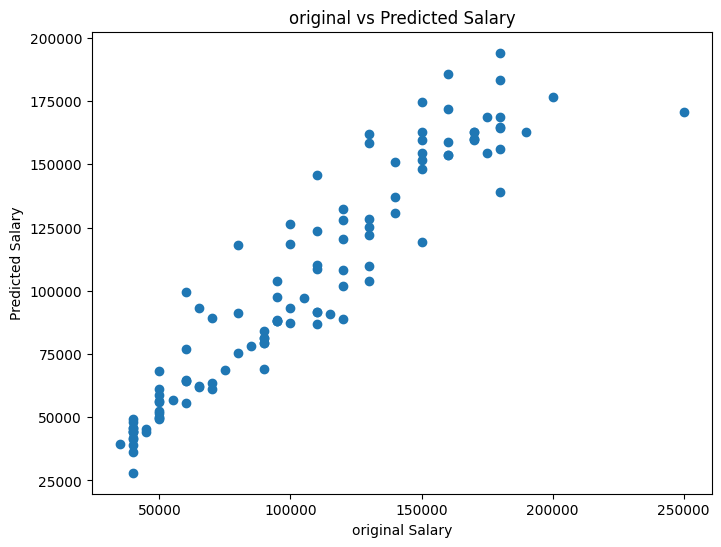

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_prediction)
plt.xlabel("original Salary")
plt.ylabel("Predicted Salary")
plt.title("original vs Predicted Salary")

plt.show()

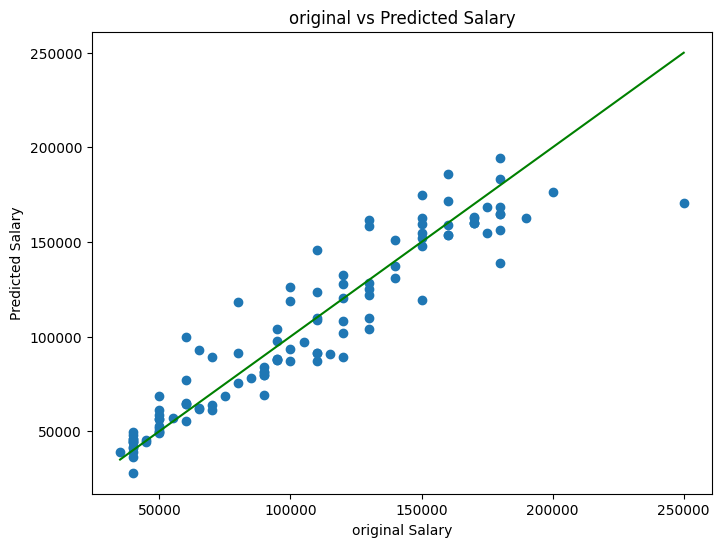

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_prediction)
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    'g'
)
plt.xlabel("original Salary")
plt.ylabel("Predicted Salary")

plt.title("original vs Predicted Salary")

plt.show()

In [ ]:
#for newone
print(LE_Gender.classes_)
print(LE_Job_Title.classes_)
print(LE_Education_Level.classes_)

['Female' 'Male']
['Account Manager' 'Accountant' 'Administrative Assistant'
 'Business Analyst' 'Business Development Manager'
 'Business Intelligence Analyst' 'CEO' 'Chief Data Officer'
 'Chief Technology Officer' 'Content Marketing Manager' 'Copywriter'
 'Creative Director' 'Customer Service Manager' 'Customer Service Rep'
 'Customer Service Representative' 'Customer Success Manager'
 'Customer Success Rep' 'Data Analyst' 'Data Entry Clerk' 'Data Scientist'
 'Digital Content Producer' 'Digital Marketing Manager' 'Director'
 'Director of Business Development' 'Director of Engineering'
 'Director of Finance' 'Director of HR' 'Director of Human Capital'
 'Director of Human Resources' 'Director of Marketing'
 'Director of Operations' 'Director of Product Management'
 'Director of Sales' 'Director of Sales and Marketing' 'Event Coordinator'
 'Financial Advisor' 'Financial Analyst' 'Financial Manager'
 'Graphic Designer' 'HR Generalist' 'HR Manager' 'Help Desk Analyst'
 'Human Resources D

In [ ]:
New_person=[22,1,1,2,4]
print(model.predict([New_person]))

[45774.93062742]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print(R2_score)

0.8851522332870745


Model efficiency 88.51 he